<a href="https://colab.research.google.com/github/Chethana-0711/ML-LAB/blob/main/boosting%20ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn matplotlib seaborn


First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                       

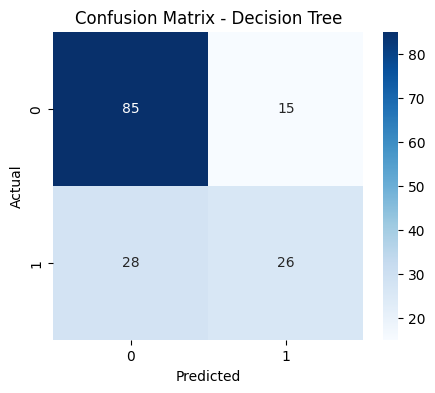


AdaBoost RESULTS
Accuracy: 0.7922

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       100
           1       0.72      0.67      0.69        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154

Confusion Matrix:
[[86 14]
 [18 36]]


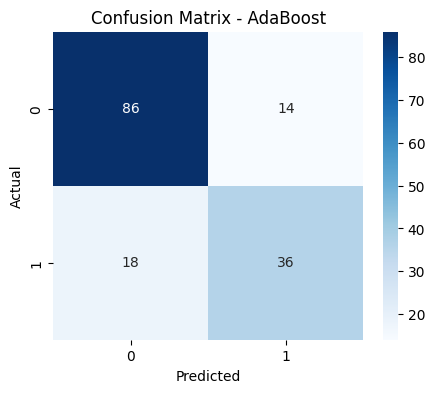


Gradient Boosting RESULTS
Accuracy: 0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:
[[84 16]
 [22 32]]


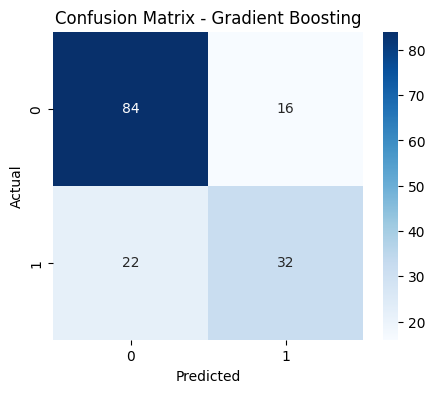


Model Comparison:
               Model  Accuracy
0      Decision Tree  0.720779
1           AdaBoost  0.792208
2  Gradient Boosting  0.753247


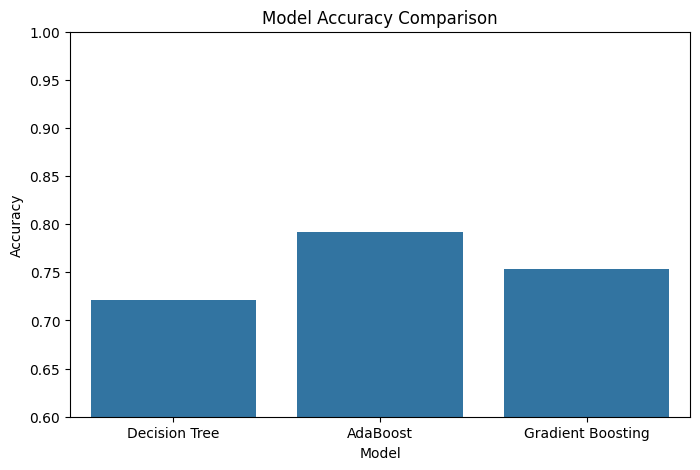

In [2]:
# ==========================================
# BOOSTING ENSEMBLE METHOD IMPLEMENTATION
# DATASET: PIMA INDIANS DIABETES
# ==========================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

column_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, header=None, names=column_names)

# Step 3: Display dataset info
print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# Step 4: Define features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Step 5: Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# MODEL 1: Decision Tree (Base Model)
# ==========================================
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

# ==========================================
# MODEL 2: AdaBoost Classifier
# ==========================================
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada_model.fit(X_train_scaled, y_train)
y_pred_ada = ada_model.predict(X_test_scaled)

# ==========================================
# MODEL 3: Gradient Boosting Classifier
# ==========================================
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate_model(model_name, y_test, y_pred):
    print("\n" + "="*50)
    print(f"{model_name} RESULTS")
    print("="*50)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Step 7: Evaluate all models
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("AdaBoost", y_test, y_pred_ada)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)

# ==========================================
# ACCURACY COMPARISON
# ==========================================
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_ada = accuracy_score(y_test, y_pred_ada)
acc_gb = accuracy_score(y_test, y_pred_gb)

results = pd.DataFrame({
    "Model": ["Decision Tree", "AdaBoost", "Gradient Boosting"],
    "Accuracy": [acc_dt, acc_ada, acc_gb]
})

print("\nModel Comparison:")
print(results)

# Plot accuracy comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.ylim(0.6, 1.0)
plt.show()